In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x8

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 2: Dataset Loading (Clean Relabeling)
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split

# 1. Define only the folders that contain FRUIT images
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# 2. Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Helper to filter and force labels to 0, 1, 2
def load_and_fix_labels(path):
    full_ds = datasets.ImageFolder(path, transform=transform)
    
    # Map class names to 0, 1, 2
    class_to_idx = {cls: i for i, cls in enumerate(fruit_classes)}
    
    new_samples = []
    for img_path, old_label in full_ds.samples:
        class_name = full_ds.classes[old_label]
        if class_name in fruit_classes:
            new_label = class_to_idx[class_name]
            new_samples.append((img_path, new_label))
            
    # Update the dataset object with fixed labels
    full_ds.samples = new_samples
    full_ds.imgs = new_samples
    full_ds.classes = fruit_classes
    full_ds.class_to_idx = class_to_idx
    return full_ds

# 4. Load from your specific Kaggle paths
base_path = '/kaggle/input/datasets/abid074/guavadiseasedatasetbyrjb/x84p2g3k6z-1'
orig_path = os.path.join(base_path, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
aug_path = os.path.join(base_path, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

orig_fruit_ds = load_and_fix_labels(orig_path)
aug_fruit_ds = load_and_fix_labels(aug_path)

# 5. Combine and Split
full_dataset = ConcatDataset([orig_fruit_ds, aug_fruit_ds])
print(f"Total Fruit Images: {len(full_dataset)}")

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# 6. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Total Fruit Images: 3183


In [4]:
# Cell 3: Model Setup
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights='DEFAULT')
num_ftrs = model.fc.in_features

# Set to 3 because we only have 3 fruit classes now
model.fc = nn.Linear(num_ftrs, 3) 

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model successfully set for 3 classes.")

Model successfully set for 3 classes.


In [5]:
import time

# Number of epochs
num_epochs = 10

print(f"Starting Training on {device}...")
print(f"Classes: {fruit_classes}")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        
        # Backward pass + optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    epoch_time = time.time() - start_time

    # Print results for the epoch
    print(f'Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.1f}s')
    print(f'  Train -> Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    print(f'  Val   -> Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')
    print('-' * 30)

print("\nTraining Complete!")

Starting Training on cuda...
Classes: ['Phytopthora', 'Scab', 'Styler and Root']
Epoch 1/10 | Time: 41.7s
  Train -> Loss: 0.2821 Acc: 0.9013
  Val   -> Loss: 0.0987 Acc: 0.9727
------------------------------
Epoch 2/10 | Time: 43.6s
  Train -> Loss: 0.1194 Acc: 0.9605
  Val   -> Loss: 0.3218 Acc: 0.9350
------------------------------
Epoch 3/10 | Time: 44.9s
  Train -> Loss: 0.0882 Acc: 0.9690
  Val   -> Loss: 0.0547 Acc: 0.9853
------------------------------
Epoch 4/10 | Time: 44.2s
  Train -> Loss: 0.0395 Acc: 0.9870
  Val   -> Loss: 0.2630 Acc: 0.9140
------------------------------
Epoch 5/10 | Time: 44.4s
  Train -> Loss: 0.0394 Acc: 0.9906
  Val   -> Loss: 0.4386 Acc: 0.8721
------------------------------
Epoch 6/10 | Time: 44.7s
  Train -> Loss: 0.1040 Acc: 0.9677
  Val   -> Loss: 0.0333 Acc: 0.9874
------------------------------
Epoch 7/10 | Time: 44.7s
  Train -> Loss: 0.0415 Acc: 0.9847
  Val   -> Loss: 0.0976 Acc: 0.9686
------------------------------
Epoch 8/10 | Time: 44.3

In [6]:
# Cell 5: Evaluation on Test Dataset
model.eval()  # Set model to evaluation mode
test_corrects = 0

print("Evaluating on Test Set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Total correct predictions
        test_corrects += torch.sum(preds == labels.data)

# Calculate final accuracy percentage
final_test_acc = (test_corrects.double() / len(test_dataset)) * 100

print(f"\nFinal Test Accuracy: {final_test_acc:.2f}%")
print(f"Total Test Images: {len(test_dataset)}")

Evaluating on Test Set...

Final Test Accuracy: 98.12%
Total Test Images: 478


In [7]:
# Define the filename
model_save_path = '/kaggle/working/resnet50_guava_fruits.pth'

# Save the state_dict (weights)
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to: {model_save_path}")
print("You can now download this file from the 'Output' section in the right sidebar.")

Model saved successfully to: /kaggle/working/resnet50_guava_fruits.pth
You can now download this file from the 'Output' section in the right sidebar.


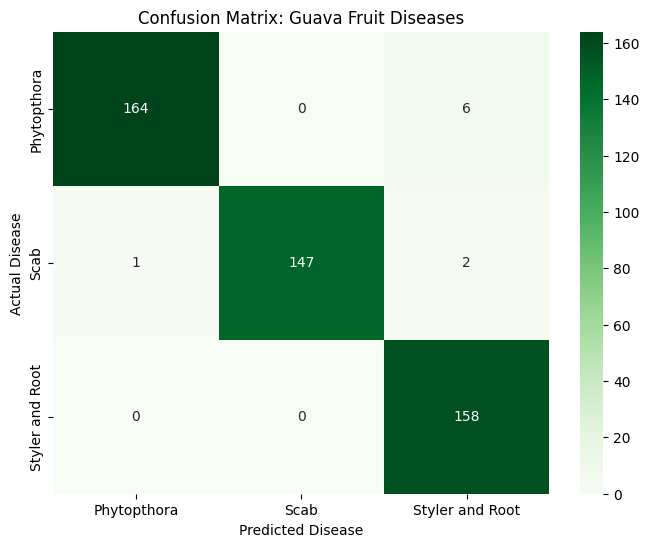


Detailed Classification Report:
                 precision    recall  f1-score   support

    Phytopthora       0.99      0.96      0.98       170
           Scab       1.00      0.98      0.99       150
Styler and Root       0.95      1.00      0.98       158

       accuracy                           0.98       478
      macro avg       0.98      0.98      0.98       478
   weighted avg       0.98      0.98      0.98       478



In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Define class names (Must match the order in fruit_classes)
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.title('Confusion Matrix: Guava Fruit Diseases')
plt.show()

# 5. Print Detailed Metrics (Precision, Recall, F1-Score)
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

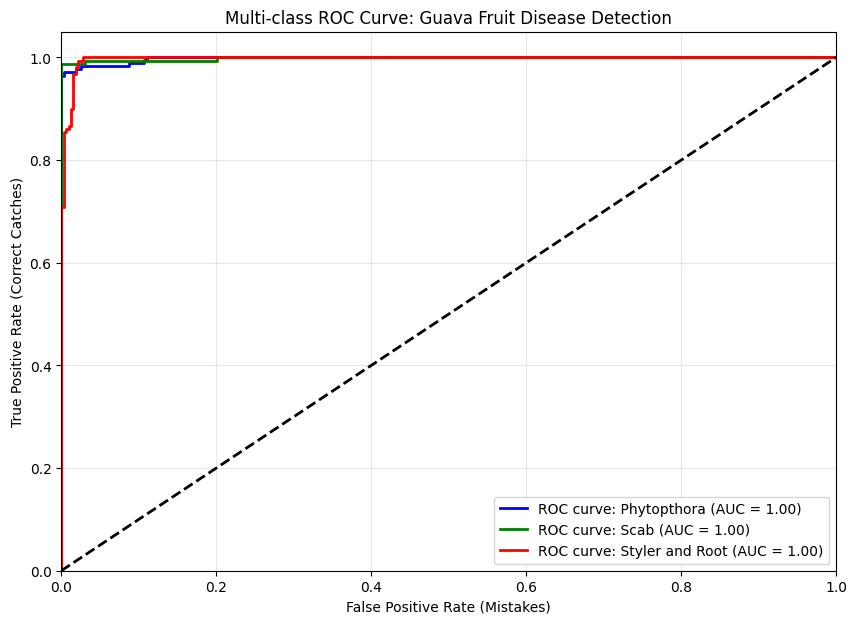

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the test set
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Softmax converts raw model output into probabilities (0 to 1)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Binarize labels for 3 classes [0, 1, 2]
n_classes = 3
bin_labels = label_binarize(all_labels, classes=[0, 1, 2])

# 3. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(bin_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'green', 'red']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve: {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot the diagonal 'random guess' line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Mistakes)')
plt.ylabel('True Positive Rate (Correct Catches)')
plt.title('Multi-class ROC Curve: Guava Fruit Disease Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()